###1.Import Libraries

In [24]:
#2.Load Data
import pandas as pd
import numpy as np

#3.(EDA)
import matplotlib.pyplot as plt
import seaborn as sns

#4.Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#5.Predictive Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#7.Dashboard
import plotly.express as px

###2.Load Data

In [25]:
from src.data.loader import load_telco_churn_data
from src.data.preprocessing import preprocess_telco_churn_data

df = load_telco_churn_data()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


###3.EDA

/tmp/ipython-input-331928641.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




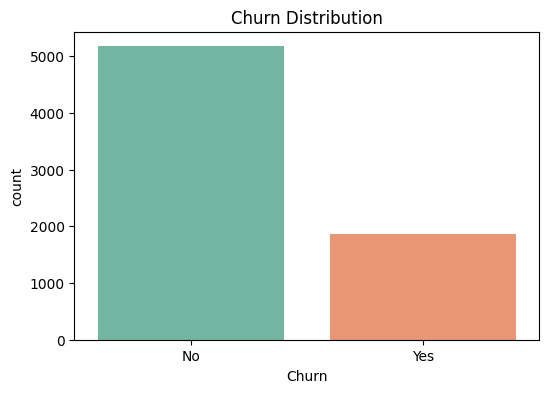

In [26]:
# 1. Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Churn Distribution")
plt.show()

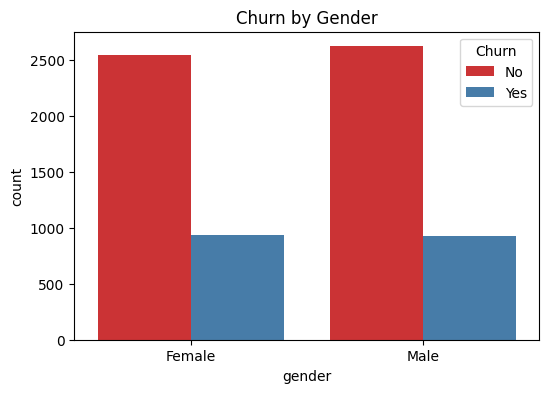

In [27]:
# 2. Gender vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df, palette="Set1")
plt.title("Churn by Gender")
plt.show()

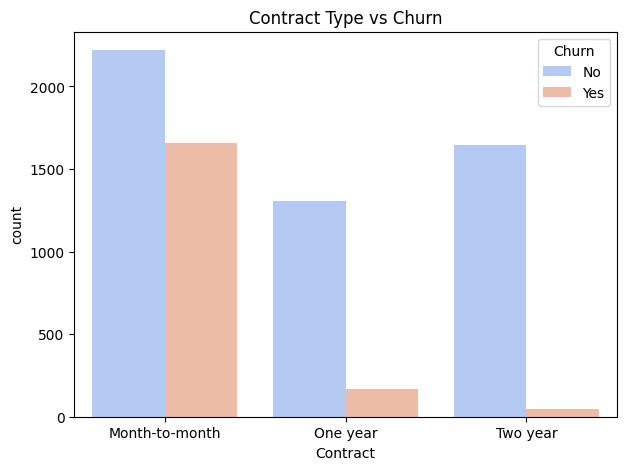

In [28]:
# 3. Contract Type vs Churn
plt.figure(figsize=(7,5))
sns.countplot(x="Contract", hue="Churn", data=df, palette="coolwarm")
plt.title("Contract Type vs Churn")
plt.show()

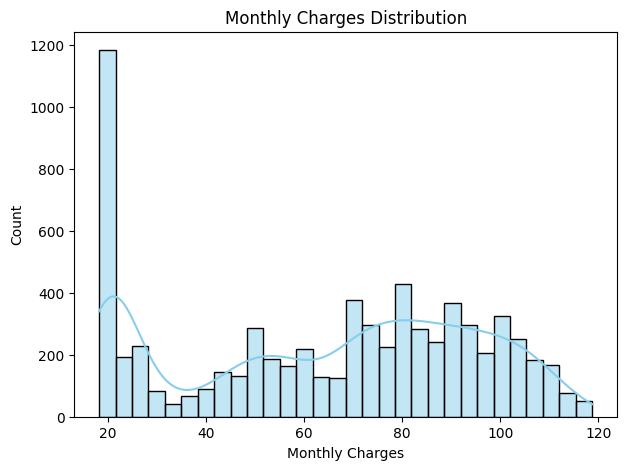

In [29]:
# 4. Monthly Charges Distribution
plt.figure(figsize=(7,5))
sns.histplot(df["MonthlyCharges"], kde=True, bins=30, color="skyblue")
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.show()

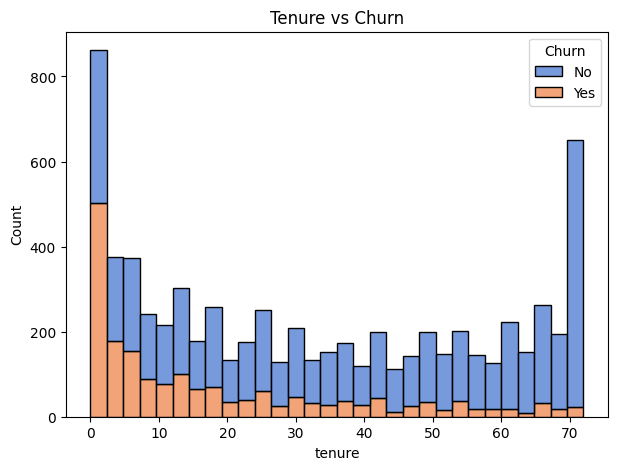

In [30]:
# 5. Tenure vs Churn
plt.figure(figsize=(7,5))
sns.histplot(x="tenure", hue="Churn", data=df, bins=30, multiple="stack", palette="muted")
plt.title("Tenure vs Churn")
plt.show()

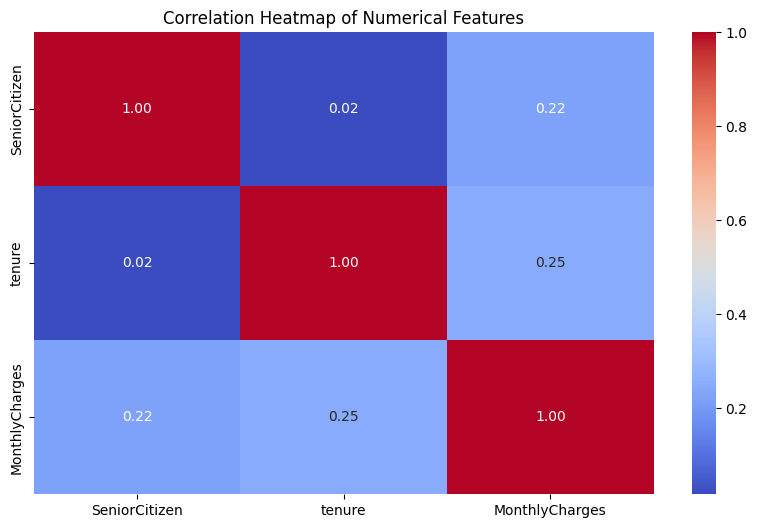

In [31]:
# 6. Correlation Heatmap (for numeric features only)
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

###4.Data Preprocessing

In [32]:
# Apply the shared preprocessing pipeline
df = preprocess_telco_churn_data(df)

In [33]:
# Preprocessing is handled by preprocess_telco_churn_data.

/tmp/ipython-input-750685809.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [34]:
# The shared preprocessing function label-encodes categorical features.

In [35]:
# Split features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [36]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

###5.Predictive Models

In [38]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("🔹 Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

🔹 Logistic Regression Results
Accuracy: 0.815471965933286
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [39]:
# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n🔹 Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


🔹 Random Forest Results
Accuracy: 0.7963094393186657
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



###6.Results Visualization

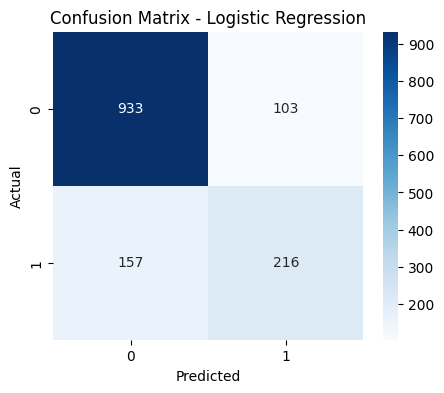

In [40]:
# Confusion Matrix for Logistic Regression
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

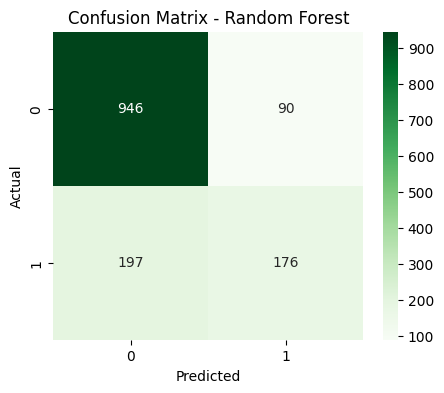

In [41]:
# Confusion Matrix for Random Forest
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/tmp/ipython-input-2150708883.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




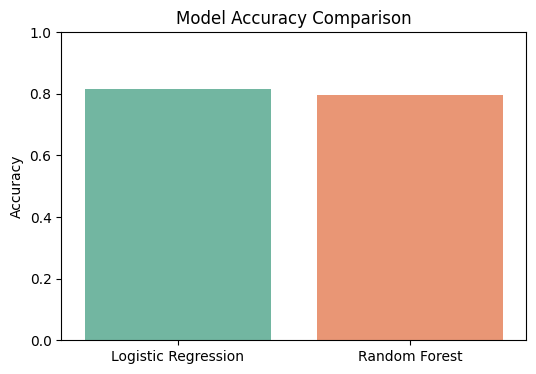

In [42]:
# Compare Model Accuracy
accuracy_scores = {
    "Logistic Regression": accuracy_score(y_test, y_pred_log),
    "Random Forest": accuracy_score(y_test, y_pred_rf)
}

plt.figure(figsize=(6,4))
sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette="Set2")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

###7.Dashboard

In [43]:
# Churn distribution
fig1 = px.histogram(df, x="Churn", color="Churn", title="Churn Distribution")
fig1.show()

In [44]:
# Contract vs Churn
fig2 = px.histogram(df, x="Contract", color="Churn", barmode="group", title="Contract Type vs Churn")
fig2.show()

In [45]:
# Monthly Charges vs Churn
fig3 = px.box(df, x="Churn", y="MonthlyCharges", color="Churn", title="Monthly Charges vs Churn")
fig3.show()